In [62]:
import warnings                                  # `do not disturb` mode
warnings.filterwarnings('ignore')

from dateutil.relativedelta import relativedelta # working with dates with style
import hvplot as hv
import hvplot.pandas
from itertools import product                    # some useful functions
import matplotlib.pyplot as plt                  # plots
import numpy as np                               # vectors and matrices
import pandas as pd                              # tables and data manipulations
from pathlib import Path
import pickle
from pypalettes import load_cmap, add_cmap
import seaborn as sns                            # more plots
from scipy.optimize import minimize              # for function minimization
import scipy.stats as scs
from sklearn.metrics import mean_absolute_percentage_error as mape
import statsmodels.api as sm
import statsmodels.formula.api                     # statistics and econometrics
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.eval_measures import rmspe, rmse
from statsmodels.tsa.api import (kpss, adfuller, seasonal_decompose, STL)
import statsmodels.tsa.api as smt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tqdm
# library für mtick
import matplotlib.ticker as mtick

# Set plot styles
plt.rcParams["figure.figsize"] = [30, 5]
plt.style.use('default')


# Festlegen der Farben
cmap = load_cmap("Apricot")
colors = ['#D72000FF', '#EE6100FF', '#FFAD0AFF', '#1BB6AFFF', 
          '#9093A2FF', '#132157FF']
cmap_continuous = add_cmap(
    colors=["#FFFFFFFF", "#FFF9A1FF", "#BAD09DFF", "#76D3CFFF", "#459E9EFF", "#306677FF", "#24385FFF", "#132157FF"],
    name="apricot_continuous",
    cmap_type="continuous"
)
cmap8 = add_cmap(
    colors=['#D72000FF', '#EE6100FF', '#FFAD0AFF', '#FFD700FF', '#1BB6AFFF', '#005F73FF', '#9093A2FF', '#132157FF'],
    name="apricot8colors",
    cmap_type="discrete"
)
cmap7 = add_cmap(
    colors=['#D72000FF', '#EE6100FF', '#FFAD0AFF', '#FFD700FF', '#1BB6AFFF', '#9093A2FF', '#132157FF'],
    name="apricot7colors",
    cmap_type="discrete"
)


%matplotlib inline

In [2]:
path = "C:/Users/ChiaraVogt/Desktop/Masterarbeit/DatenLigue180/"

In [3]:
# Load Timestamp of Dataset
d2014 = pd.read_csv(path + "ligue180-2014.csv", encoding='utf-8-sig', delimiter=';', usecols=['data_atendimento'])
d2015 = pd.read_csv(path + "ligue180-2015.csv", encoding='utf-8-sig', delimiter=';', usecols=['data_atendimento'])
d2016 = pd.read_csv(path + "ligue180-2016.csv", encoding='utf-8-sig', delimiter=';', usecols=['data_atendimento'])
d2017 = pd.read_csv(path + "ligue180-2017.csv", encoding='utf-8-sig', delimiter=';', usecols=['data_atendimento'])
d2018 = pd.read_csv(path + "ligue180-2018.csv", encoding='utf-8-sig', delimiter=';', usecols=['data_atendimento'])
d2018_2 = pd.read_csv(path + "ligue180-nov-2018.csv", encoding='utf-8-sig', delimiter=';', usecols=['data_atendimento'])
d2019 = pd.read_csv(path + "ligue180-2019.csv", encoding='utf-8-sig', delimiter=';', usecols=['data_atendimento'])
d2020 = pd.read_csv(path + "ligue180-primeiro-semestre-2020.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_da_denúncia'])
d2020_2 = pd.read_csv(path + "ligue180-segundo-semestre-2020.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data de cadastro'])
d2021 = pd.read_csv(path + "ligue180-primeiro-semestre-2021.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data de cadastro'])
d2021_2 = pd.read_csv(path + "ligue180-segundo-semestre-2021.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data de cadastro'])
d2022 = pd.read_csv(path + "ligue180-primeiro-semestre-2022.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data de cadastro'])
d2022_2 = pd.read_csv(path + "ligue180-segundo-semestre-2022.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_de_cadastro'])
d2023 = pd.read_csv(path + "ligue180-primeiro-semestre-2023.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_de_cadastro'])
d2023_2 = pd.read_csv(path + "ligue180-segundo-semestre-2023.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_de_cadastro'])

# Timestamp angleichen
d2014['data_atendimento'] = pd.to_datetime(d2014['data_atendimento'], dayfirst = True)
d2015['data_atendimento'] = pd.to_datetime(d2015['data_atendimento'])
d2016['data_atendimento'] = pd.to_datetime(d2016['data_atendimento'], dayfirst = True)
d2017['data_atendimento'] = pd.to_datetime(d2017['data_atendimento'])
d2018['data_atendimento'] = pd.to_datetime(d2018['data_atendimento'])
d2018_2['data_atendimento'] = pd.to_datetime(d2018_2['data_atendimento'])
d2019['data_atendimento'] = pd.to_datetime(d2019['data_atendimento'])
d2020['Data_da_denúncia'] = pd.to_datetime(d2020['Data_da_denúncia'], dayfirst = True)
d2020_2['Data de cadastro'] = pd.to_datetime(d2020_2['Data de cadastro'], dayfirst = True)
d2021['Data de cadastro'] = pd.to_datetime(d2021['Data de cadastro'], dayfirst = True)
d2021_2['Data de cadastro'] = pd.to_datetime(d2021_2['Data de cadastro'], dayfirst = True)
d2022['Data de cadastro'] = pd.to_datetime(d2022['Data de cadastro'], dayfirst = True)
d2022_2['Data_de_cadastro'] = pd.to_datetime(d2022_2['Data_de_cadastro'], dayfirst = True)
d2023['Data_de_cadastro'] = pd.to_datetime(d2023['Data_de_cadastro'], dayfirst = True)
d2023_2['Data_de_cadastro'] = pd.to_datetime(d2023_2['Data_de_cadastro'], dayfirst = True)

# Spaltennamen angleichen
d2014 = d2014.rename(columns = {'data_atendimento' : 'date'})
d2015 = d2015.rename(columns = {'data_atendimento' : 'date'})
d2016 = d2016.rename(columns = {'data_atendimento' : 'date'})
d2017 = d2017.rename(columns = {'data_atendimento' : 'date'})
d2018 = d2018.rename(columns = {'data_atendimento' : 'date'})
d2018_2 = d2018_2.rename(columns = {'data_atendimento' : 'date'})
d2019 = d2019.rename(columns = {'data_atendimento' : 'date'})
d2020 = d2020.rename(columns = {'Data_da_denúncia' : 'date'})
d2020_2 = d2020_2.rename(columns = {'Data de cadastro' : 'date'})
d2021 = d2021.rename(columns = {'Data de cadastro' : 'date'})
d2021_2 = d2021_2.rename(columns = {'Data de cadastro' : 'date'})
d2022 = d2022.rename(columns = {'Data de cadastro' : 'date'})
d2022_2 = d2022_2.rename(columns = {'Data_de_cadastro' : 'date'})
d2023 = d2023.rename(columns = {'Data_de_cadastro' : 'date'})
d2023_2 = d2023_2.rename(columns = {'Data_de_cadastro' : 'date'})

# Zeitreihen zu Datensatz verbinden
data_call_all = pd.concat([d2014, d2015, d2016, d2017, d2018, d2018_2, d2019, d2020, d2020_2, d2021, d2021_2, d2022, d2022_2, d2023, d2023_2], ignore_index = True)
data_call_all.set_index('date', inplace=True)
data_call_all

# Für Testdatensatz Timestamp laden
d2024 = pd.read_csv(path+"ligue180-primeiro-semestre-2024.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_de_cadastro'])
d2024['Data_de_cadastro'] = pd.to_datetime(d2024['Data_de_cadastro'], format = 'mixed')
d2024 = d2024.rename(columns = {'Data_de_cadastro' : 'date'})
d2024.set_index('date', inplace=True)

C:\Users\ChiaraVogt\AppData\Local\Temp\ipykernel_2672\3863447473.py:19: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d2014['data_atendimento'] = pd.to_datetime(d2014['data_atendimento'], dayfirst = True)
C:\Users\ChiaraVogt\AppData\Local\Temp\ipykernel_2672\3863447473.py:21: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d2016['data_atendimento'] = pd.to_datetime(d2016['data_atendimento'], dayfirst = True)
C:\Users\ChiaraVogt\AppData\Local\Temp\ipykernel_2672\3863447473.py:33: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d2023_2['Data_de_cadastro'] = pd.to_datetime(d2023_2['Data_de_cadastro'], dayfirst = True)


Vermutlich gibt es einige Daten bei denen die Uhrzeit nicht festgehalten ist und alle Daten des Tages auf 00:00:00 datiert sind. Diese Werte sind für die Tagesanalyse hilfreich, verfälschen jedoch die Ergebnisse der Stunden. Deshalb werden für alle Berechnungen mit Stunden diese Werte herausgefiltert. 

In [64]:
# Vergleich zu Gesamtzeitreihe
# Filtern der Einträge, bei denen die Uhrzeit nicht 00:00:00 ist
data_call_all_hourly = data_call_all[data_call_all.index.time != pd.Timestamp('00:00:00').time()]
print(data_call_all.shape)
print(data_call_all_hourly.shape)
print(data_call_all_hourly.shape[0] / data_call_all.shape[0] * 100) # Prozentualer Anteil der Einträge mit Uhrzeit != 00:00:00
# Für Testdaten
# Filtern der Einträge, bei denen die Uhrzeit nicht 00:00:00 ist
d2024_call_all_hourly = d2024[d2024.index.time != pd.Timestamp('00:00:00').time()]
print("------------Testdaten------------")
print(d2024.shape)
print(d2024_call_all_hourly.shape)
print(d2024_call_all_hourly.shape[0] / d2024.shape[0] * 100) # Prozentualer Anteil der Einträge mit Uhrzeit != 00:00:00

(2406097, 0)
(1811098, 0)
75.27119646464794
------------Testdaten------------
(394154, 0)
(394154, 0)
100.0


Wie hier schon zu sehen gibt es viele Daten bei denen im Zeitstempel keine Uhrzeit angegeben ist, wegen denen alle Daten des Tages auf 00:00:00 datiert sind. Diese Werte sind für die Tagesanalyse hilfreich, verfälschen jedoch die Ergebnisse der Stunden. 

In [65]:
# Verarbeiten der Datensätze in calls/hour (df_hourly)
df_hourly = data_call_all_hourly.resample('h').size().reset_index(name='calls')
df_hourly.set_index('date', inplace=True)

# Für Testdaten
# Verarbeiten der Datensätze in calls/hour (df_hourly)
df_hourly_2024 = d2024_call_all_hourly.resample('h').size().reset_index(name='calls')
df_hourly_2024.set_index('date', inplace=True)

In [75]:
df_hourly.shape

(45294, 1)

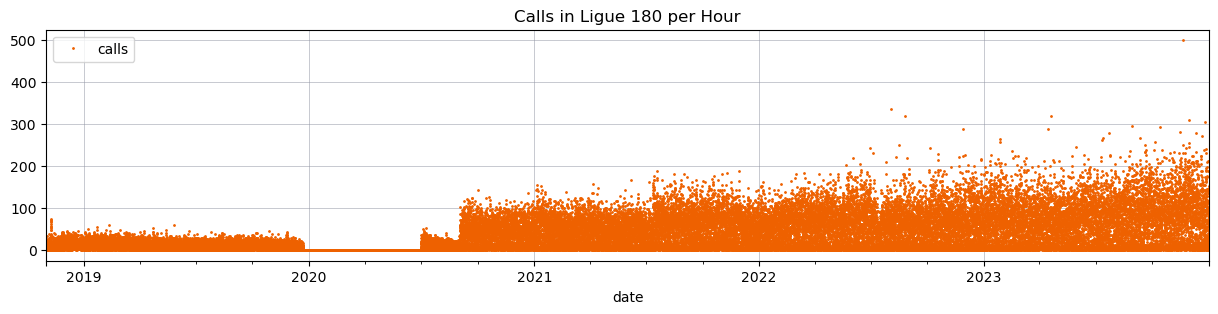

In [71]:
df_hourly.plot(style='.', color = cmap.colors[1], figsize=(15,3), markersize=2, title='Calls in Ligue 180 per Hour')
plt.grid(color='#9093A2FF', linestyle="-", linewidth=0.5, alpha=0.7)
plt.show()

## Remove Duplicates
*hash*-Column existiert in Datensatz von 2020 bis 2023. Der gleiche *hash* existiert teilweise mehrmals:

In [7]:
# Load Timestamp of Dataset
path = "C:/Users/ChiaraVogt/Desktop/Masterarbeit/DatenLigue180/"
d2020 = pd.read_csv(path + "ligue180-primeiro-semestre-2020.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_da_denúncia', 'hash_par_vitima_suspeito'])
d2020_2 = pd.read_csv(path + "ligue180-segundo-semestre-2020.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data de cadastro', 'hash'])
d2021 = pd.read_csv(path + "ligue180-primeiro-semestre-2021.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data de cadastro', 'hash'])
d2021_2 = pd.read_csv(path + "ligue180-segundo-semestre-2021.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data de cadastro', 'hash'])
d2022 = pd.read_csv(path + "ligue180-primeiro-semestre-2022.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data de cadastro', 'hash'])
d2022_2 = pd.read_csv(path + "ligue180-segundo-semestre-2022.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_de_cadastro', 'hash'])
d2023 = pd.read_csv(path + "ligue180-primeiro-semestre-2023.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_de_cadastro', 'hash'])
d2023_2 = pd.read_csv(path + "ligue180-segundo-semestre-2023.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_de_cadastro', 'hash'])

# Timestamp angleichen
d2020['Data_da_denúncia'] = pd.to_datetime(d2020['Data_da_denúncia'], dayfirst = True)
d2020_2['Data de cadastro'] = pd.to_datetime(d2020_2['Data de cadastro'], dayfirst = True)
d2021['Data de cadastro'] = pd.to_datetime(d2021['Data de cadastro'], dayfirst = True)
d2021_2['Data de cadastro'] = pd.to_datetime(d2021_2['Data de cadastro'], dayfirst = True)
d2022['Data de cadastro'] = pd.to_datetime(d2022['Data de cadastro'], dayfirst = True)
d2022_2['Data_de_cadastro'] = pd.to_datetime(d2022_2['Data_de_cadastro'], dayfirst = True)
d2023['Data_de_cadastro'] = pd.to_datetime(d2023['Data_de_cadastro'], dayfirst = True)
d2023_2['Data_de_cadastro'] = pd.to_datetime(d2023_2['Data_de_cadastro'], dayfirst = True)

# Spaltennamen angleichen
d2020 = d2020.rename(columns = {'Data_da_denúncia' : 'date', 'hash_par_vitima_suspeito' : 'hash'})
d2020_2 = d2020_2.rename(columns = {'Data de cadastro' : 'date'})
d2021 = d2021.rename(columns = {'Data de cadastro' : 'date'})
d2021_2 = d2021_2.rename(columns = {'Data de cadastro' : 'date'})
d2022 = d2022.rename(columns = {'Data de cadastro' : 'date'})
d2022_2 = d2022_2.rename(columns = {'Data_de_cadastro' : 'date'})
d2023 = d2023.rename(columns = {'Data_de_cadastro' : 'date'})
d2023_2 = d2023_2.rename(columns = {'Data_de_cadastro' : 'date'})

# Zeitreihen zu Datensatz verbinden
data_call_hash_all = pd.concat([d2020, d2020_2, d2021, d2021_2, d2022, d2022_2, d2023, d2023_2], ignore_index = True)
data_call_hash_all['date'] = data_call_hash_all['date'].dt.strftime('%Y-%m-%d %H:%M:%S')
data_call_hash_all['date'] = pd.to_datetime(data_call_hash_all['date'], dayfirst = True,format='%Y-%m-%d %H:%M:%S')

# Für Testdaten
d2024_hash = pd.read_csv(path + "ligue180-primeiro-semestre-2024.csv", encoding='utf-8-sig', delimiter=';', usecols=['Data_de_cadastro', 'hash'])
d2024_hash['Data_de_cadastro'] = pd.to_datetime(d2024_hash['Data_de_cadastro'], format='mixed')
d2024_hash = d2024_hash.rename(columns = {'Data_de_cadastro' : 'date'})
d2024_hash['date'] = d2024_hash['date'].dt.strftime('%Y-%m-%d %H:%M:%S')
d2024_hash['date'] = pd.to_datetime(d2024_hash['date'], dayfirst = True,format='%Y-%m-%d %H:%M:%S')

d2024_hash

C:\Users\ChiaraVogt\AppData\Local\Temp\ipykernel_2672\3081847086.py:20: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d2023_2['Data_de_cadastro'] = pd.to_datetime(d2023_2['Data_de_cadastro'], dayfirst = True)


,hash,date
0,ADCED6E583BF5600AC69908DD5925E84809602D98FF1FA...,2024-01-01 00:15:43
1,ADCED6E583BF5600AC69908DD5925E84809602D98FF1FA...,2024-01-01 00:15:43
2,ADCED6E583BF5600AC69908DD5925E84809602D98FF1FA...,2024-01-01 00:15:43
3,3ABB8F1D7A6E12902F3D7E38D5235DBBDD8FFAC935DB6F...,2024-01-01 00:20:59
4,3ABB8F1D7A6E12902F3D7E38D5235DBBDD8FFAC935DB6F...,2024-01-01 00:20:59
...,...,...
394149,04E85CB4617F9F23D7F75419F58B22E2995CB9638A99BC...,2024-06-30 23:53:19
394150,13CAA5DA95F20AEFFC9E4C32CFFB3E72157757F1F793FA...,2024-06-30 23:53:19
394151,13CAA5DA95F20AEFFC9E4C32CFFB3E72157757F1F793FA...,2024-06-30 23:53:19
394152,13CAA5DA95F20AEFFC9E4C32CFFB3E72157757F1F793FA...,2024-06-30 23:53:19


In [8]:
# Datetimeformat für Daten setzen, Zeitstempel als Index
data_call_hash_all['date'] = pd.to_datetime(data_call_hash_all['date'], errors='coerce')
data_call_hash_all.set_index('date', inplace=True)

# Für Testdaten
d2024_hash['date'] = pd.to_datetime(d2024_hash['date'], errors='coerce')
d2024_hash.set_index('date', inplace=True)

In [9]:
# Herausfiltern der Timestamps, bei denen die Uhrzeit nicht 00:00:00 ist
print(f"Beispiel für Zeitstempel im Index: {data_call_hash_all.index[:5]}")
# Einträge filtern, bei denen die Uhrzeit nicht 00:00:00 ist
data_call_hash_all_hourly = data_call_hash_all[data_call_hash_all.index.time != pd.Timestamp('00:00:00').time()]
data_call_hash_all_hourly.head()


Beispiel für Zeitstempel im Index: DatetimeIndex(['2020-04-09', '2020-02-15', '2020-06-14', '2020-03-24',
               '2020-05-31'],
              dtype='datetime64[ns]', name='date', freq=None)


,hash
date,
2020-07-02 14:18:00,35666ce2a5a539bdb67ab4c0bbc94eff
2020-07-03 20:14:00,38e27ee59745df105461fa4818053355
2020-07-15 19:31:00,30984674c4c0dac02e2ebcd456d41e0c
2020-07-15 14:21:00,4ad777b83c76090c8f2a0caf9e382e00
2020-07-07 17:41:00,3d1f0b2bb714da65b50b6849c61ea487


Im Folgenden werden die mehrmals vorkommenden Hashtags analysiert. Es wird vermutet, dass diese den gleichen Anruf und die gleiche Anzeige betreffen.

In [10]:
hash_counts = data_call_hash_all['hash'].value_counts()
# Dataframe hash_counts soll nur bei mind. 2 value_counts() den hash und die Menge an Vorkomnissen speichern
hash_counts = hash_counts[hash_counts >= 2]
print("Anzahl der Hashes mit mind. 2 Vorkommen: ")
print(hash_counts.head(10))

Anzahl der Hashes mit mind. 2 Vorkommen: 
hash
d2d9664e8a2fb21d0a441753b3532b3a                                    69
AC15EA832A6206870051921C7657119DEB34DD7E24C672D7B0C7514F9E371EC3    62
8A3F1EB84C2612D48ABB28418FF2E81BFD81C8125318C178BA02D7B39182BF2A    62
48CEE01DD6E73A76286D0C5C96E29071668CEBEAFEE5C39D3D49B1B617433D6E    62
F14E6B290167E66FCC0469A51267A0F2F3591FE837F72104D6C9A318A2D16253    62
044FBDC51CCA0AAF96D8D0C738795350DAC073D84564C1ACBE835888E27F8D6E    62
51408d8b591d665bddf34d5aaef59bff                                    50
D7C484B367258B0DD6214ACBAEDB48647B9A0B54307BF72303B9F112CB714AFA    45
674F57F8EBDE018B3255A2565EB332465F5DAE31A6C0FD3695DA91D778844F39    45
f8c2fac27add47c5d7b4a4a46a330c37                                    39
Name: count, dtype: int64


In [11]:
# Summe aller hash die doppelt oder mehr vorkommen
sum_duplicate_entries = hash_counts.sum()
# Gesamtanteil an den Einträgen in data_call_all
total_entries = len(data_call_hash_all)
# Prozentsatz der Einträge, die doppelt oder mehr vorkommen
percent_duplicate_entries = (sum_duplicate_entries / total_entries) * 100
# ab 2014
percent_duplicate_entries_2014 = (sum_duplicate_entries / len(data_call_all)) * 100
# Berechne die Anzahl der einzigartigen Hashes (einen Eintrag pro Hash)
unique_hash_entries = len(data_call_hash_all) - hash_counts.sum() + len(hash_counts)
# Prozentsatz der Einträge, wenn man nur einen Eintrag pro Hash hätte
percent_unique_hash_entries = (unique_hash_entries / total_entries) * 100
# ab 2014
percent_unique_hash_entries_2014 = (unique_hash_entries + (len(data_call_all) - len(data_call_hash_all))) / len(data_call_all) * 100
# Ergebnisse anzeigen
print(f"Summe aller Einträge: {len(data_call_all)}")
print(f"Summe der Einträge, die doppelt oder mehr vorkommen: {sum_duplicate_entries}")
print(f"Menge aller Einträge (2020-2023): {len(data_call_hash_all)}")
print(f"Anzahl der hash, die nicht mehrfach vorkommen: {len(data_call_hash_all)-sum_duplicate_entries}")
print(f"Prozentualer Anteil der doppelten Einträge am Gesamtdatensatz (2020-2023): {percent_duplicate_entries:.2f}%")
print(f"Prozentualer Anteil der doppelten Einträge am Gesamtdatensatz (2014-2023): {percent_duplicate_entries_2014:.2f}%")
print(f"Summe aller Einträge, ohne Duplikate: {len(data_call_all) - len(data_call_hash_all) + unique_hash_entries}")
print(f"Anzahl der einzigartigen Hashes (jeweils ein Eintrag): {unique_hash_entries}")
print(f"Prozentualer Anteil des Menge der Einträge (2020-2023) bei Entfernen der Duplikate: {percent_unique_hash_entries:.2f}%")
print(f"Prozentualer Anteil des Menge der Einträge (2014-2023) bei Entfernen der Duplikate: {percent_unique_hash_entries_2014:.2f}%")

Summe aller Einträge: 2406097
Summe der Einträge, die doppelt oder mehr vorkommen: 1649615
Menge aller Einträge (2020-2023): 1739566
Anzahl der hash, die nicht mehrfach vorkommen: 89951
Prozentualer Anteil der doppelten Einträge am Gesamtdatensatz (2020-2023): 94.83%
Prozentualer Anteil der doppelten Einträge am Gesamtdatensatz (2014-2023): 68.56%
Summe aller Einträge, ohne Duplikate: 1069407
Anzahl der einzigartigen Hashes (jeweils ein Eintrag): 402876
Prozentualer Anteil des Menge der Einträge (2020-2023) bei Entfernen der Duplikate: 23.16%
Prozentualer Anteil des Menge der Einträge (2014-2023) bei Entfernen der Duplikate: 44.45%


Es sind sehr viele hashs die sehr häufig vorkommen. Ein erster Blick in die Daten lässt vermuten, dass es sich um die gleiche Anzeige oder um die gleichen Personen  handelt, da auch die Zeit die gleiche ist. Im folgenden werden die hashs im Gesamtdatensatz stichprobenartig untersucht.  

In [39]:
# Import aller Daten, um zu prüfen, ob der gleiche Hashtag die gleiche Anzeige sein könnte
d2020 = pd.read_csv(path + "ligue180-primeiro-semestre-2020.csv", encoding='utf-8-sig', delimiter=';')
d2020_2 = pd.read_csv(path + "ligue180-segundo-semestre-2020.csv", encoding='utf-8-sig', delimiter=';')
d2021 = pd.read_csv(path + "ligue180-primeiro-semestre-2021.csv", encoding='utf-8-sig', delimiter=';')
d2021_2 = pd.read_csv(path + "ligue180-segundo-semestre-2021.csv", encoding='utf-8-sig', delimiter=';')
d2022 = pd.read_csv(path + "ligue180-primeiro-semestre-2022.csv", encoding='utf-8-sig', delimiter=';')
d2022_2 = pd.read_csv(path + "ligue180-segundo-semestre-2022.csv", encoding='utf-8-sig', delimiter=';')
d2023 = pd.read_csv(path + "ligue180-primeiro-semestre-2023.csv", encoding='utf-8-sig', delimiter=';')
d2023_2 = pd.read_csv(path + "ligue180-segundo-semestre-2023.csv", encoding='utf-8-sig', delimiter=';')

#Timestamp angleichen
d2020['Data_da_denúncia'] = pd.to_datetime(d2020['Data_da_denúncia'], dayfirst = True)
d2020_2['Data de cadastro'] = pd.to_datetime(d2020_2['Data de cadastro'], dayfirst = True)
d2021['Data de cadastro'] = pd.to_datetime(d2021['Data de cadastro'], dayfirst = True)
d2021_2['Data de cadastro'] = pd.to_datetime(d2021_2['Data de cadastro'], dayfirst = True)
d2022['Data de cadastro'] = pd.to_datetime(d2022['Data de cadastro'], dayfirst = True)
d2022_2['Data_de_cadastro'] = pd.to_datetime(d2022_2['Data_de_cadastro'], dayfirst = True)
d2023['Data_de_cadastro'] = pd.to_datetime(d2023['Data_de_cadastro'], dayfirst = True)
d2023_2['Data_de_cadastro'] = pd.to_datetime(d2023_2['Data_de_cadastro'], dayfirst = True)

# Angeleichen der Spaltennamen für 2020 bis 2022 auf die Spaltenbezeichnungen von 2023
d2020 = d2020.rename(columns={'hash_par_vitima_suspeito':'hash', 
                              'Data_da_denúncia': 'Data_de_cadastro', 
                              'Canal_de_atendimento':'Canal_de_atendimento', 
                              'Denúncia_Emergencial':'Denúncia_emergencial', 
                              'motivacoes': 'Motivação', 
                              'Relação_Suspeito_x_Vítima': 'Relação_vítima_suspeito', 
                              'orientacao_sexual': 'Orientação_sexual_da_vítima', 
                              'idade_vitima': 'Faixa_etária_da_vítima', 
                              'deficiencia_vitima':'Deficiência_da_vítima', 
                              'Nacionalidade_da_vítima': 'Nacionalidade_da_vítima', 
                              'País_de_orígem_da_vítima': 'País_da_vítima', 
                              'Grau_instrução_da_vítima': 'Grau_de_instrução_da_vítima', 
                              'Raça_cor_da_vítima': 'Raça_Cor_da_vítima', 
                              'idade_suspeito': 'Faixa_etária_do_suspeito', 
                              'Nacionalidade_do_suspeito': 'Suspeito_nacionalidade',
                              'deficiencia_suspeito': 'Deficiência_do_suspeito', 
                              'País_de_orígem_do_suspeito': 'País_do_suspeito', 
                              'Raça_cor_do_suspeito': 'Raça_Cor_do_suspeito', 
                              'Etnia_do_suspeito': 'Suspeito_Etnia', 
                              'violacoes': 'violacao'})
d2020_2 = d2020_2.rename(columns={'Data de cadastro': 'Data_de_cadastro', 'Canal de atendimento': 'Canal_de_atendimento', 
                              'Denúncia emergencial':'Denúncia_emergencial', 'Cenário da violação': 'Cenário_da_violação', 
                               'Início das violações': 'Início_das_violações', 'Grupo vulnerável': 'Grupo_vulnerável', 
                              'Relação vítima-suspeito': 'Relação_vítima_suspeito', 'Gênero da vítima': 'Gênero_da_vítima', 
                                  'Orientação sexual da vítima': 'Orientação_sexual_da_vítima', 'Faixa etária da vítima': 
                                  'Faixa_etária_da_vítima', 'Nacionalidade da vítima': 'Nacionalidade_da_vítima', 
                                  'Deficiência da vítima':'Deficiência_da_vítima', 'Doença rara da vítima': 'Doença_rara_da_vítima',
                                  'Deficiência relacionada a doença rara ?': 'Deficiência_relacionada_a_doença_rara', 
                                  'Vítima preso(a)': 'Vítima_preso_a', 'País da vítima': 'País_da_vítima', 'UF da vítima': 'UF_da_vítima',
                                  'Município  da vítima': 'Município_da_vítima', 'Profissão da vítima': 'Profissão_da_vítima', 
                                  'Grau de instrução da vítima': 'Grau_de_instrução_da_vítima', 'Religião da vítima': 'Religião_da_vítima', 
                                  'Raça\Cor da vítima': 'Raça_Cor_da_vítima', 'Etnia da vítima': 'Etnia_da_vítima', 
                                  'Faixa de renda da vítima': 'Faixa_de_renda_da_vítima', 'Natureza Jurídica do Suspeito': 'Natureza_Jurídica_do_Suspeito',
                                  'Gênero do suspeito': 'Gênero_do_suspeito', 'Orientação sexual do suspeito': 'Orientação_sexual_do_suspeito',
                                  'Faixa etária do suspeito': 'Faixa_etária_do_suspeito', 'Suspeito nacionalidade': 'Suspeito_nacionalidade',
                                  'Deficiência do suspeito': 'Deficiência_do_suspeito', 'Doença rara do suspeito': 'Doença_rara_do_suspeito',
                                  'Deficiência relacionada a doença rara (suspeito) ?': 'Deficiência_relacionada_a_doença_rara_suspeito', 
                                  'Suspeito preso': 'Suspeito_preso', 'País do suspeito': 'País_do_suspeito', 'UF do suspeito': 'UF_do_suspeito',
                                  'Profissão do suspeito': 'Profissão_do_suspeito', 'Grau de instrução do suspeito': 'Grau_de_instrução_do_suspeito',
                                  'Religião do suspeito': 'Religião_do_suspeito', 'Raça\Cor do suspeito': 'Raça_Cor_do_suspeito', 
                                  'Suspeito Etnia': 'Suspeito_Etnia', 'Faixa de renda do suspeito': 'Faixa_de_renda_do_suspeito', 
                                  'Vínculo Órgão\PJ do suspeito': 'Vínculo_Órgão_PJ_do_suspeito'})
d2021 = d2021.rename(columns={'Data de cadastro': 'Data_de_cadastro', 'Canal de atendimento': 'Canal_de_atendimento', 
                              'Denúncia emergencial':'Denúncia_emergencial', 'Cenário da violação': 'Cenário_da_violação', 
                               'Início das violações': 'Início_das_violações', 'Grupo vulnerável': 'Grupo_vulnerável', 
                              'Relação vítima-suspeito': 'Relação_vítima_suspeito', 'Gênero da vítima': 'Gênero_da_vítima', 
                                  'Orientação sexual da vítima': 'Orientação_sexual_da_vítima', 'Faixa etária da vítima': 
                                  'Faixa_etária_da_vítima', 'Nacionalidade da vítima': 'Nacionalidade_da_vítima', 
                                  'Deficiência da vítima':'Deficiência_da_vítima', 'Doença rara da vítima': 'Doença_rara_da_vítima',
                                  'Deficiência relacionada a doença rara ?': 'Deficiência_relacionada_a_doença_rara', 
                                  'Vítima preso(a)': 'Vítima_preso_a', 'País da vítima': 'País_da_vítima', 'UF da vítima': 'UF_da_vítima',
                                  'Município  da vítima': 'Município_da_vítima', 'Profissão da vítima': 'Profissão_da_vítima', 
                                  'Grau de instrução da vítima': 'Grau_de_instrução_da_vítima', 'Religião da vítima': 'Religião_da_vítima', 
                                  'Raça\Cor da vítima': 'Raça_Cor_da_vítima', 'Etnia da vítima': 'Etnia_da_vítima', 
                                  'Faixa de renda da vítima': 'Faixa_de_renda_da_vítima', 'Natureza Jurídica do Suspeito': 'Natureza_Jurídica_do_Suspeito',
                                  'Gênero do suspeito': 'Gênero_do_suspeito', 'Orientação sexual do suspeito': 'Orientação_sexual_do_suspeito',
                                  'Faixa etária do suspeito': 'Faixa_etária_do_suspeito', 'Suspeito nacionalidade': 'Suspeito_nacionalidade',
                                  'Deficiência do suspeito': 'Deficiência_do_suspeito', 'Doença rara do suspeito': 'Doença_rara_do_suspeito',
                                  'Deficiência relacionada a doença rara (suspeito) ?': 'Deficiência_relacionada_a_doença_rara_suspeito', 
                                  'Suspeito preso': 'Suspeito_preso', 'País do suspeito': 'País_do_suspeito', 'UF do suspeito': 'UF_do_suspeito',
                                  'Profissão do suspeito': 'Profissão_do_suspeito', 'Grau de instrução do suspeito': 'Grau_de_instrução_do_suspeito',
                                  'Religião do suspeito': 'Religião_do_suspeito', 'Raça\Cor do suspeito': 'Raça_Cor_do_suspeito', 
                                  'Suspeito Etnia': 'Suspeito_Etnia', 'Faixa de renda do suspeito': 'Faixa_de_renda_do_suspeito', 
                                  'Vínculo Órgão\PJ do suspeito': 'Vínculo_Órgão_PJ_do_suspeito'})
d2021_2 = d2021_2.rename(columns={'Data de cadastro': 'Data_de_cadastro', 'Canal de atendimento': 'Canal_de_atendimento',
                                  'Denúncia emergencial':'Denúncia_emergencial', 'Cenário da violação': 'Cenário_da_violação', 
                                  'Início das violações': 'Início_das_violações', 'Grupo vulnerável': 'Grupo_vulnerável', 
                                  'Relação vítima-suspeito': 'Relação_vítima_suspeito', 'Gênero da vítima': 'Gênero_da_vítima', 
                                  'Orientação sexual da vítima': 'Orientação_sexual_da_vítima', 'Faixa etária da vítima': 
                                  'Faixa_etária_da_vítima', 'Nacionalidade da vítima': 'Nacionalidade_da_vítima', 
                                  'Deficiência da vítima':'Deficiência_da_vítima', 'Doença rara da vítima': 'Doença_rara_da_vítima',
                                  'Deficiência relacionada a doença rara ?': 'Deficiência_relacionada_a_doença_rara', 
                                  'Vítima preso(a)': 'Vítima_preso_a', 'País da vítima': 'País_da_vítima', 'UF da vítima': 'UF_da_vítima',
                                  'Município  da vítima': 'Município_da_vítima', 'Profissão da vítima': 'Profissão_da_vítima', 
                                  'Grau de instrução da vítima': 'Grau_de_instrução_da_vítima', 'Religião da vítima': 'Religião_da_vítima', 
                                  'Raça\Cor da vítima': 'Raça_Cor_da_vítima', 'Etnia da vítima': 'Etnia_da_vítima', 
                                  'Faixa de renda da vítima': 'Faixa_de_renda_da_vítima', 'Natureza Jurídica do Suspeito': 'Natureza_Jurídica_do_Suspeito',
                                  'Gênero do suspeito': 'Gênero_do_suspeito', 'Orientação sexual do suspeito': 'Orientação_sexual_do_suspeito',
                                  'Faixa etária do suspeito': 'Faixa_etária_do_suspeito', 'Suspeito nacionalidade': 'Suspeito_nacionalidade',
                                  'Deficiência do suspeito': 'Deficiência_do_suspeito', 'Doença rara do suspeito': 'Doença_rara_do_suspeito',
                                  'Deficiência relacionada a doença rara (suspeito) ?': 'Deficiência_relacionada_a_doença_rara_suspeito', 
                                  'Suspeito preso': 'Suspeito_preso', 'País do suspeito': 'País_do_suspeito', 'UF do suspeito': 'UF_do_suspeito',
                                  'Profissão do suspeito': 'Profissão_do_suspeito', 'Grau de instrução do suspeito': 'Grau_de_instrução_do_suspeito',
                                  'Religião do suspeito': 'Religião_do_suspeito', 'Raça\Cor do suspeito': 'Raça_Cor_do_suspeito', 
                                  'Suspeito Etnia': 'Suspeito_Etnia', 'Faixa de renda do suspeito': 'Faixa_de_renda_do_suspeito', 
                                  'Vínculo Órgão\PJ do suspeito': 'Vínculo_Órgão_PJ_do_suspeito'})
d2022 = d2022.rename(columns={'Data de cadastro': 'Data_de_cadastro', 'Canal de atendimento': 'Canal_de_atendimento',

                                  'Denúncia emergencial':'Denúncia_emergencial', 'Cenário da violação': 'Cenário_da_violação', 
                                  'Início das violações': 'Início_das_violações', 'Grupo vulnerável': 'Grupo_vulnerável', 
                                  'Relação vítima-suspeito': 'Relação_vítima_suspeito', 'Gênero da vítima': 'Gênero_da_vítima', 
                                  'Orientação sexual da vítima': 'Orientação_sexual_da_vítima', 'Faixa etária da vítima': 
                                  'Faixa_etária_da_vítima', 'Nacionalidade da vítima': 'Nacionalidade_da_vítima', 
                                  'Deficiência da vítima':'Deficiência_da_vítima', 'Doença rara da vítima': 'Doença_rara_da_vítima',
                                  'Deficiência relacionada a doença rara ?': 'Deficiência_relacionada_a_doença_rara', 
                                  'Vítima preso(a)': 'Vítima_preso_a', 'País da vítima': 'País_da_vítima', 'UF da vítima': 'UF_da_vítima',
                                  'Município  da vítima': 'Município_da_vítima', 'Profissão da vítima': 'Profissão_da_vítima', 
                                  'Grau de instrução da vítima': 'Grau_de_instrução_da_vítima', 'Religião da vítima': 'Religião_da_vítima', 
                                  'Raça\Cor da vítima': 'Raça_Cor_da_vítima', 'Etnia da vítima': 'Etnia_da_vítima', 
                                  'Faixa de renda da vítima': 'Faixa_de_renda_da_vítima', 'Natureza Jurídica do Suspeito': 'Natureza_Jurídica_do_Suspeito',
                                  'Gênero do suspeito': 'Gênero_do_suspeito', 'Orientação sexual do suspeito': 'Orientação_sexual_do_suspeito',
                                  'Faixa etária do suspeito': 'Faixa_etária_do_suspeito', 'Suspeito nacionalidade': 'Suspeito_nacionalidade',
                                  'Deficiência do suspeito': 'Deficiência_do_suspeito', 'Doença rara do suspeito': 'Doença_rara_do_suspeito',
                                  'Deficiência relacionada a doença rara (suspeito) ?': 'Deficiência_relacionada_a_doença_rara_suspeito', 
                                  'Suspeito preso': 'Suspeito_preso', 'País do suspeito': 'País_do_suspeito', 'UF do suspeito': 'UF_do_suspeito',
                                  'Profissão do suspeito': 'Profissão_do_suspeito', 'Grau de instrução do suspeito': 'Grau_de_instrução_do_suspeito',
                                  'Religião do suspeito': 'Religião_do_suspeito', 'Raça\Cor do suspeito': 'Raça_Cor_do_suspeito', 
                                  'Suspeito Etnia': 'Suspeito_Etnia', 'Faixa de renda do suspeito': 'Faixa_de_renda_do_suspeito', 
                                  'Vínculo Órgão\PJ do suspeito': 'Vínculo_Órgão_PJ_do_suspeito'})

# Alle Jahre in ein Dataframe packen
data_all_2020 = pd.concat([d2020, d2020_2, d2021, d2021_2, d2022, d2022_2, d2023, d2023_2], ignore_index= True)

<>:53: SyntaxWarning: invalid escape sequence '\C'
<>:61: SyntaxWarning: invalid escape sequence '\C'
<>:63: SyntaxWarning: invalid escape sequence '\P'
<>:75: SyntaxWarning: invalid escape sequence '\C'
<>:83: SyntaxWarning: invalid escape sequence '\C'
<>:85: SyntaxWarning: invalid escape sequence '\P'
<>:97: SyntaxWarning: invalid escape sequence '\C'
<>:105: SyntaxWarning: invalid escape sequence '\C'
<>:107: SyntaxWarning: invalid escape sequence '\P'
<>:120: SyntaxWarning: invalid escape sequence '\C'
<>:128: SyntaxWarning: invalid escape sequence '\C'
<>:130: SyntaxWarning: invalid escape sequence '\P'
<>:53: SyntaxWarning: invalid escape sequence '\C'
<>:61: SyntaxWarning: invalid escape sequence '\C'
<>:63: SyntaxWarning: invalid escape sequence '\P'
<>:75: SyntaxWarning: invalid escape sequence '\C'
<>:83: SyntaxWarning: invalid escape sequence '\C'
<>:85: SyntaxWarning: invalid escape sequence '\P'
<>:97: SyntaxWarning: invalid escape sequence '\C'
<>:105: SyntaxWarning: inv

In [40]:
# Erster Hash-Wert aus hash_counts (der hash mit den meisten Vorkommen)
first_hash = hash_counts.index[0]
print(f"Hash: {first_hash}")

# Alle Zeilen in data_all_2020 mit diesem Hash-Wert
matching_rows = data_all_2020[data_all_2020['hash'] == first_hash]

# Erste gefundene Zeile mit allen Variablen
first_match = matching_rows.iloc[0]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        print("\nErster Treffer mit allen Variablen:")
        print(first_match)

# Überprüfen, ob alle anderen Spalten für diesen Hash identische Werte haben
# Zeilen vergleichen
differences = matching_rows.drop(columns=['hash']).nunique()

# Unterschiede ausgeben (Spalten, in denen unterschiedliche Werte vorkommen)
differing_columns = differences[differences > 1]

if differing_columns.empty:
    print("\nAlle Zeilen mit dem Hash haben identische Werte in allen anderen Spalten.")
else:
    print("\nUnterschiede gefunden in folgenden Spalten:")
    for col in differing_columns.index:
        unique_values = matching_rows[col].unique()
        print(f"Spalte '{col}': Unterschiedliche Werte = {unique_values}")


Hash: d2d9664e8a2fb21d0a441753b3532b3a

Erster Treffer mit allen Variablen:
hash                                                               d2d9664e8a2fb21d0a441753b3532b3a
Data_de_cadastro                                                                2022-06-17 09:34:00
Denunciante                                                                                 ANÔNIMO
relacao_demandante_vitima                                                                       NaN
Canal_de_atendimento                                                                     TELEFÔNICO
País_da_vítima                                                                               BRASIL
UF                                                                                               MG
Estado                                                                                          NaN
Município                                                                               BOM SUCESSO
Cenário_da_violação     

In [41]:
hash_table = matching_rows.copy()
hash_table

,hash,Data_de_cadastro,Denunciante,relacao_demandante_vitima,Canal_de_atendimento,País_da_vítima,UF,Estado,Município,Cenário_da_violação,...,Suspeito_preso,UF_do_suspeito,sl_suspeito_municipio,Profissão_do_suspeito,Grau_de_instrução_do_suspeito,Religião_do_suspeito,Vínculo_Órgão_PJ_do_suspeito,sl_suspeito_ramo,suspeito_especificacao_etnia,vitima_especificacao_etnia
857387,d2d9664e8a2fb21d0a441753b3532b3a,2022-06-17 09:34:00,ANÔNIMO,NaN,TELEFÔNICO,BRASIL,MG,NaN,BOM SUCESSO,CASA DO SUSPEITO,...,N/D,MG,BOM SUCESSO,CONSELHEIRO TUTELAR,N/D,N/D,NaN,N/D,N/D,N/D
857394,d2d9664e8a2fb21d0a441753b3532b3a,2022-06-17 09:34:00,ANÔNIMO,NaN,TELEFÔNICO,BRASIL,MG,NaN,BOM SUCESSO,CASA DO SUSPEITO,...,N/D,MG,BOM SUCESSO,CONSELHEIRO TUTELAR,N/D,N/D,NaN,N/D,N/D,N/D
857395,d2d9664e8a2fb21d0a441753b3532b3a,2022-06-17 09:34:00,ANÔNIMO,NaN,TELEFÔNICO,BRASIL,MG,NaN,BOM SUCESSO,CASA DO SUSPEITO,...,N/D,MG,BOM SUCESSO,CONSELHEIRO TUTELAR,N/D,N/D,NaN,N/D,N/D,N/D
857400,d2d9664e8a2fb21d0a441753b3532b3a,2022-06-17 09:34:00,ANÔNIMO,NaN,TELEFÔNICO,BRASIL,MG,NaN,BOM SUCESSO,CASA DO SUSPEITO,...,N/D,MG,BOM SUCESSO,CONSELHEIRO TUTELAR,N/D,N/D,NaN,N/D,N/D,N/D
857403,d2d9664e8a2fb21d0a441753b3532b3a,2022-06-17 09:34:00,ANÔNIMO,NaN,TELEFÔNICO,BRASIL,MG,NaN,BOM SUCESSO,CASA DO SUSPEITO,...,N/D,MG,BOM SUCESSO,CONSELHEIRO TUTELAR,N/D,N/D,NaN,N/D,N/D,N/D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
878628,d2d9664e8a2fb21d0a441753b3532b3a,2022-06-17 09:34:00,ANÔNIMO,NaN,TELEFÔNICO,BRASIL,MG,NaN,BOM SUCESSO,CASA DO SUSPEITO,...,N/D,MG,BOM SUCESSO,CONSELHEIRO TUTELAR,N/D,N/D,NaN,N/D,N/D,N/D
880009,d2d9664e8a2fb21d0a441753b3532b3a,2022-06-17 09:34:00,ANÔNIMO,NaN,TELEFÔNICO,BRASIL,MG,NaN,BOM SUCESSO,CASA DO SUSPEITO,...,N/D,MG,BOM SUCESSO,CONSELHEIRO TUTELAR,N/D,N/D,NaN,N/D,N/D,N/D
880018,d2d9664e8a2fb21d0a441753b3532b3a,2022-06-17 09:34:00,ANÔNIMO,NaN,TELEFÔNICO,BRASIL,MG,NaN,BOM SUCESSO,CASA DO SUSPEITO,...,N/D,MG,BOM SUCESSO,CONSELHEIRO TUTELAR,N/D,N/D,NaN,N/D,N/D,N/D
880024,d2d9664e8a2fb21d0a441753b3532b3a,2022-06-17 09:34:00,ANÔNIMO,NaN,TELEFÔNICO,BRASIL,MG,NaN,BOM SUCESSO,CASA DO SUSPEITO,...,N/D,MG,BOM SUCESSO,CONSELHEIRO TUTELAR,N/D,N/D,NaN,N/D,N/D,N/D


hash[0]: d2d9664e8a2fb21d0a441753b3532b3a  
Unterschiede in  
- violacao: 'INTEGRIDADE>PATRIMONIAL>INDIVIDUAL' 
    - 'INTEGRIDADE>FÍSICA>MAUS TRATOS'
    - 'INTEGRIDADE>PSÍQUICA>AMEAÇA ou COAÇÃO'
    - 'INTEGRIDADE>PSÍQUICA>CONSTRANGIMENTO'
- Motivacao:
    - viele verschiedene Anschuldigungen
- Profissão_do_suspeito:
    - CONSELHEIRO TUTELAR
    -> dadurch, dass dieser Wert immer der gleiche ist, lässt es darauf schließen, dass es sich um einen Menschen oder eine "Arbeitsgemeinschaft" handelt, der/die in mehreren Aspekten ihr Amt missbraucht hat/haben

Auch bei hash[1]: AC15EA832A6206870051921C7657119DEB34DD7E24C672D7B0C7514F9E371EC3  
zeigt sich dass das Arbeitsfeld des Beschuldigten immer das gleiche ist: PODER EXECUTIVO EM GERAL - MUNICIPAL
auch hier ist der Zeitstempel der gleiche. 
Hier gibt es viele Unterschiede in der Spalte violacao, jedoch sind es Straftaten, die "zusammenpassen", wie z.B.  
- 'LIBERDADE>SEXUAL>FÍSICA>ESTUPRO' -> Vergewaltigung
- 'INTEGRIDADE>FÍSICA>MAUS TRATOS' -> physische Misshandlung
- 'LIBERDADE>SEXUAL>FÍSICA>ABUSO SEXUAL FÍSICO' -> physischer sexueller Übergriff
- 'LIBERDADE>DIREITOS INDIVIDUAIS>STALKING' -> Stalking
TODO
Bei hash[10]: CDBEF147F8BFD6E6D63535DE2B51465DD58C6E089A43BE30AD77AAF6C13C8081  
handelt es sich um eine andere Situation. Hier zeigt eine dritte Person, jemanden an, der/die sich zu verschiedenen Personen schlecht verhalten hat:  
Spalte 'Cenário_da_violação': Unterschiedliche Werte = ['CASA ONDE RESIDE A VÍTIMA E O SUSPEITO' 'OUTROS']  
Spalte 'Gênero_da_vítima': Unterschiedliche Werte = ['FEMININO' 'MASCULINO']  
Spalte 'Faixa_etária_da_vítima': Unterschiedliche Werte = [**'25 A 29 ANOS' '06 ANOS' '12 ANOS' '05 ANOS'**]  
Spalte 'Raça_Cor_da_vítima': Unterschiedliche Werte = ['PARDA' 'PRETA']  
Spalte 'Relação_vítima_suspeito': Unterschiedliche Werte = [**'COMPANHEIRO(A)' 'MÃE' 'VIZINHO(A)'**]  
Spalte 'violacao': Unterschiedliche Werte = ['INTEGRIDADE>FÍSICA>MAUS TRATOS' 'INTEGRIDADE>FÍSICA>TORTURA FÍSICA'  
 'INTEGRIDADE>FÍSICA>OUTROS' 'DIREITOS SOCIAIS>SAÚDE'  
 'INTEGRIDADE>FÍSICA>ABANDONO'  
 'INTEGRIDADE>FÍSICA>EXPOSIÇÃO DE RISCO À SAÚDE'  
 'INTEGRIDADE>PSÍQUICA>EXPOSIÇÃO'  
 'INTEGRIDADE>FÍSICA>AGRESSÃO ou VIAS DE FATO'  
 'INTEGRIDADE>PSÍQUICA>CONSTRANGIMENTO'  
 'INTEGRIDADE>PSÍQUICA>TORTURA PSÍQUICA' 'INTEGRIDADE>NEGLIGÊNCIA'  
 'DIREITOS SOCIAIS>PROTEÇÃO À INFÂNCIA'  
 'INTEGRIDADE>PSÍQUICA>AMEAÇA ou COAÇÃO' 'DIREITOS SOCIAIS>SEGURANÇA']  
Spalte 'Motivação': Unterschiedliche Werte = [nan 'MOTIVAÇÃO.EM RAZÃO DA CONDIÇÃO SOCIAL' 'OUTRO(S) ELEMENTO(S)']  
Spalte 'Frequência': Unterschiedliche Werte = ['DIARIAMENTE' 'SEMANALMENTE']  
Spalte 'Início_das_violações': Unterschiedliche Werte = ['HÁ MAIS DE UM ANO' 'HÁ MAIS DE SEIS MESES']  
Spalte 'UF_da_vítima': Unterschiedliche Werte = ['BA' 'DENUNCIANTE NÃO SOUBE INFORMAR']  
Spalte 'Município_da_vítima': Unterschiedliche Werte = ['291360 | ILHÉUS' 'DENUNCIANTE NÃO SOUBE INFORMAR']  


Unterschiede zeigen sich nur in Art der Gewalt, es scheint darum zu gehen mehrere verschiedene Gewaltformen anzuzeigen. Als nächstes wird geprüft, ob es gleiche Hashes mit unterschiedlichem Zeitstempel gibt.

In [42]:
# Ziel:
# Prüfung, ob DataFrame (`data_call_hash_all`) doppelte Hash-Werte hat,
# die mit unterschiedlichen Zeitstempeln (in der Spalte 'date') gespeichert werden.

# Spalte 'date' als Index
if 'date' in data_call_hash_all.columns:
    data_call_hash_all.set_index('date', inplace=True)

# Zählen, wie oft jeder Hash vorkommt
duplicate_hashes = data_call_hash_all['hash'].value_counts()

# Nur Hashes behalten, die mehr als einmal vorkommen
duplicate_hashes = duplicate_hashes[duplicate_hashes > 1].index

# Alle Zeilen mit mehrfach vorkommenden Hashes filtern
duplicate_rows = data_call_hash_all[data_call_hash_all['hash'].isin(duplicate_hashes)]

# Von diesen Duplikaten nur jene behalten, die mit unterschiedlichen Zeitstempeln vorkommen
different_timestamp_rows = duplicate_rows.groupby('hash').filter(
    lambda x: len(x.index.unique()) > 1
)

# Ausgabe der Zeilen mit identischem Hash, aber unterschiedlichen Zeitstempeln
print(different_timestamp_rows)

Empty DataFrame
Columns: [hash]
Index: []


In [43]:
# Gleicher Test für Testdaten
if 'date' in d2024_hash.columns:
    d2024_hash.set_index('date', inplace=True)

# Hashes, die mehr als einmal vorkommen
duplicate_hashes = d2024_hash['hash'].value_counts()
duplicate_hashes = duplicate_hashes[duplicate_hashes > 1].index
# 3. Filtern der Zeilen, die doppelte Hashes enthalten
duplicate_rows = d2024_hash[d2024_hash['hash'].isin(duplicate_hashes)]
# Prüfen, ob alle Zeitstempel innerhalb der Gruppen gleich sind
different_timestamp_rows = duplicate_rows.groupby('hash').filter(
    lambda x: len(x.index.unique()) > 1  # Prüfen auf unterschiedliche Zeitstempel im Index
)
print(different_timestamp_rows)

Empty DataFrame
Columns: [hash]
Index: []


Der Dataframe ist leer, also haben alle Zeilen mit gleichem hash auch den gleichen Zeitstempel.

In [46]:
# Löschen der Duplikate
# Neuer Dataframe ohne Duplikate
data_call_nodupl = data_call_hash_all_hourly.drop_duplicates(subset='hash', keep='first')
print(data_call_nodupl.head(5))
# Überprüfen, ob Menge der Ergebnisse gleich berechneter Menge von Einträgen ist
print(f"\nErwartete Anzahl der einzigartigen Hashes (jeweils ein Eintrag): {unique_hash_entries}")
print(f"Tatsächliche Anzahl der einzigartigen Hashes (jeweils ein Eintrag): {len(data_call_nodupl)}")

# Für Testdaten
# Neuer Dataframe ohne Duplikate
d2024_nodupl = d2024_hash.drop_duplicates(subset='hash', keep='first')
print(d2024_nodupl.head(5))
# Überprüfen, ob Menge der Ergebnisse gleich berechneter Menge von Einträgen ist
print(f"Einzigartige Hashes (jeweils ein Eintrag): {len(d2024_nodupl)}")

                                                 hash
date                                                 
2020-07-02 14:18:00  35666ce2a5a539bdb67ab4c0bbc94eff
2020-07-03 20:14:00  38e27ee59745df105461fa4818053355
2020-07-15 19:31:00  30984674c4c0dac02e2ebcd456d41e0c
2020-07-15 14:21:00  4ad777b83c76090c8f2a0caf9e382e00
2020-07-07 17:41:00  3d1f0b2bb714da65b50b6849c61ea487

Erwartete Anzahl der einzigartigen Hashes (jeweils ein Eintrag): 402876
Tatsächliche Anzahl der einzigartigen Hashes (jeweils ein Eintrag): 344467
                                                                  hash
date                                                                  
2024-01-01 00:15:43  ADCED6E583BF5600AC69908DD5925E84809602D98FF1FA...
2024-01-01 00:20:59  3ABB8F1D7A6E12902F3D7E38D5235DBBDD8FFAC935DB6F...
2024-01-01 01:44:49  CA1987A2BDCBA28655AA18341533006A28D5D577CBF69B...
2024-01-01 02:15:38  CA524A4EEC18EF1B96D32442ED2D9C984513FDCB7EB9D2...
2024-01-01 02:38:52  3F33A268BFEC2B5E0274C03638A

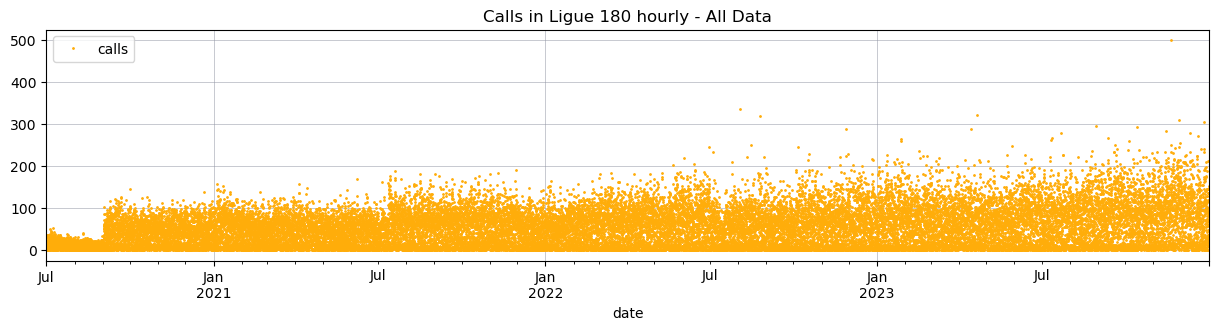

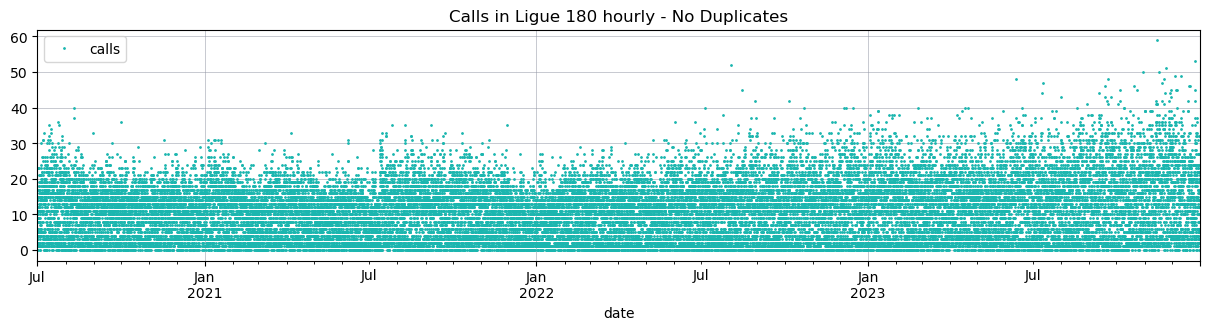

In [74]:
# Erstellen des Dataframes für Time Series Prediction - Ohne Duplikate - 2020 - 2023
df_hourly_nodupl_2020 = data_call_nodupl.resample('h').size().reset_index(name='calls')
df_hourly_nodupl_2020.set_index('date', inplace=True)
# Erstellen des Dataframes für Time Series Prediction - Alle Daten - 2020 - 2023
df_hourly_2020 = data_call_hash_all_hourly.resample('h').size().reset_index(name='calls')
df_hourly_2020.set_index('date', inplace=True)
df_hourly_2020.plot(style='.', color = cmap.colors[2], markersize=2, figsize=(15,3), title='Calls in Ligue 180 hourly - All Data')
plt.grid(color='#9093A2FF', linestyle="-", linewidth=0.5, alpha=0.7)
plt.show()
df_hourly_nodupl_2020.plot(style='.', color = cmap.colors[3], markersize=2, figsize=(15,3), title='Calls in Ligue 180 hourly - No Duplicates')
plt.grid(color='#9093A2FF', linestyle="-", linewidth=0.5, alpha=0.7)
plt.show()

## days_to_holiday hinzufügen

Hinzufügen der exogenen Variable days_to_holiday: diese zeigt in Integerwerten den Abstand zum Feiertag an. Quelle ist der Datensatz aus dem Paket Pythonpaket holidays.  
Wert 2: noch 2 Tage bis zum Feiertag  
Wert -2: 2 Tage nach dem Feiertag

In [36]:
import holidays
from datetime import date
from holidays import Brazil

br_holidays = Brazil(years=[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
holidays_list = list(br_holidays.keys())  

# Funktion zum Berechnen des minimalen Abstands zu einem Feiertag
def calculate_days_to_holiday(row_date, holidays):
    if pd.isna(row_date):  # Überprüfen, ob das Datum leer ist
        return None
    
    # Konvertiere row_date in ein date-Objekt, falls es ein Timestamp ist
    row_date = row_date.date() if isinstance(row_date, pd.Timestamp) else row_date
    
    days_to_holidays = [(holiday - row_date).days for holiday in holidays]
    
    if days_to_holidays:  # Überprüfen, ob die Liste nicht leer ist
        return min(days_to_holidays, key=abs)  # Der kleinste absolute Abstand (vorher/nachher)
    else:
        return None  # Falls keine Feiertage vorhanden sind


c:\Users\ChiaraVogt\miniconda3\Lib\site-packages\holidays\__init__.py:32: FutureIncompatibilityWarning: 

This is a future version incompatibility warning from Python Holidays library v0.54
to inform you about an upcoming change in our API versioning strategy that may affect your
project's dependencies. Starting from version 1.0 onwards, we will be following a loose form of
Semantic Versioning (SemVer, https://semver.org) to provide clearer communication regarding any
potential breaking changes.

This means that while we strive to maintain backward compatibility, there might be occasional
updates that introduce breaking changes to our API. To ensure the stability of your projects,
we highly recommend pinning the version of our API that you rely on. You can pin your current
holidays v0.x dependency (e.g., holidays==0.54) or limit it (e.g., holidays<1.0) in order to
avoid potentially unwanted upgrade to the version 1.0 when it's released (ETA 2024Q4 - 2025Q1).

If you have any questions 

In [55]:
df_hourly_nodupl_2020.reset_index(inplace=True)

# Die Abstandsspalte basierend auf den Feiertagen berechnen
df_hourly_nodupl_2020['days_to_holiday'] = df_hourly_nodupl_2020['date'].apply(lambda x: calculate_days_to_holiday(x, holidays_list))

# Ausgabe zur Überprüfung
df_hourly_nodupl_2020.head()

,date,calls,days_to_holiday
0,2020-07-01 00:00:00,1,-61
1,2020-07-01 01:00:00,5,-61
2,2020-07-01 02:00:00,4,-61
3,2020-07-01 03:00:00,2,-61
4,2020-07-01 04:00:00,1,-61


In [57]:
# Für Testdaten
# Prüfen, ob der DataFrame None oder leer ist
print(d2024_nodupl is None)  # True, wenn d2024_nodupl nicht definiert wurde
if d2024_nodupl is not None:
    print(d2024_nodupl.empty)  # True, wenn der DataFrame leer ist

# Prüfen, ob die Spalte 'date' existiert
if d2024_nodupl is not None:
    print(d2024_nodupl.columns)  # Listet alle Spaltennamen auf

False
False
Index(['hash'], dtype='object')


In [58]:
# Für Testdaten
d2024_nodupl.reset_index(inplace=True)

# Die Abstandsspalte basierend auf den Feiertagen berechnen
d2024_nodupl['days_to_holiday'] = d2024_nodupl['date'].apply(lambda x: calculate_days_to_holiday(x, holidays_list))

# Ausgabe zur Überprüfung
d2024_nodupl.tail(20)

C:\Users\ChiaraVogt\AppData\Local\Temp\ipykernel_2672\1395838870.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2024_nodupl['days_to_holiday'] = d2024_nodupl['date'].apply(lambda x: calculate_days_to_holiday(x, holidays_list))


,date,hash,days_to_holiday
71397,2024-06-30 22:21:52,2FB8CCD1961C9AE56BD8E518C29B9FEDBD216634BD7AB2...,-60
71398,2024-06-30 22:36:51,41D3EAC6603B44254B324AA26AD93ECB723876DC15FDF1...,-60
71399,2024-06-30 22:39:43,0E232A554D2B180DC46F67B0B2A33C2EFD5CF485473FDA...,-60
71400,2024-06-30 22:39:43,2FC1AF6E8F5C8ABA17608C65E0436DE00E790B6869B168...,-60
71401,2024-06-30 22:44:39,1ACA6B5570DF52FD77AD164D646C37952A71AC3A79A6D4...,-60
71402,2024-06-30 22:51:16,3B298D9A6842B0342253FA6F66A1444410B2E7B9AFFCB8...,-60
71403,2024-06-30 22:52:20,29B45E2F2F6A7F1BCD6F050BAD77654485E36814B4837E...,-60
71404,2024-06-30 23:05:09,97C316644BFE3A9202B106F15C05E721DAAFCD70938A21...,-60
71405,2024-06-30 23:06:03,B77281C486FE5E119CB29B24977BE2CF95FBE5F382650A...,-60
71406,2024-06-30 23:12:29,02AE2B3364FB14BFA4D178297EDAB73756BC51E9B032E5...,-60


## Fehlende Daten für hourly_calls

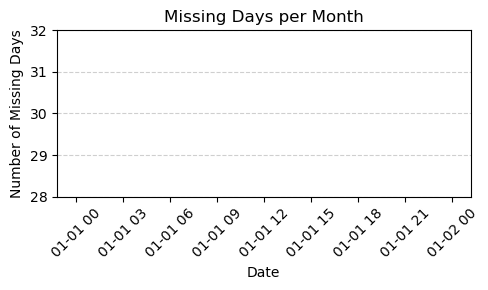

Series([], Freq: ME, dtype: int64)


In [63]:
def missing_days_per_month_continuous(df):
    # Sicherstellen, dass die 'date'-Spalte als datetime formatiert ist
    df['date'] = pd.to_datetime(df['date'])

    # Liste aller Tage im Zeitraum des DataFrames erstellen
    start_date = df['date'].min().normalize()
    end_date = df['date'].max().normalize()
    all_days = pd.date_range(start=start_date, end=end_date, freq='d')

    # Liste der Tage, die im bereinigten DataFrame fehlen
    cleaned_days = df['date'].dt.normalize().unique()
    missing_days = set(all_days) - set(cleaned_days)

    # Neuer DataFrame mit der Anzahl der fehlenden Tage pro Monat
    missing_days_series = pd.Series(1, index=pd.to_datetime(list(missing_days)))
    missing_days_per_month = missing_days_series.resample('ME').sum().sort_index()

    plt.figure(figsize=(5, 3))
    plt.plot(missing_days_per_month.index, missing_days_per_month, marker='o', color=cmap.colors[0], linestyle='-', label='Missing Days')

    # Werte annotieren
    for i, val in enumerate(missing_days_per_month):
        plt.text(missing_days_per_month.index[i], val + 0.2, str(int(val)), ha='center', fontsize=10)

    plt.title('Missing Days per Month')
    plt.xlabel('Date')
    plt.ylabel('Number of Missing Days')
    plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))
    plt.xticks(rotation=45)
    plt.ylim(28, 32)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return missing_days_per_month


# Beispielaufruf der Funktion
missing_days_summary = missing_days_per_month_continuous(df_hourly_nodupl_2020)
print(missing_days_summary)

In [ ]:
Hier ist eine Lücke von einem halben Jahr, was ca. 10 % des Datensatzes entspricht.  
